# Library imports and file reading

In [1]:
# Code written by Konstantin Kazantsev Dolgikh, 04/03/2026
# This code analyzes and cleans the following dataset: https://www.kaggle.com/datasets/arindam235/startup-investments-crunchbase

# Library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Graph style configuration
plt.style.use('ggplot')
sns.set_palette("viridis")

# File reading
# The file won't open with the default encoding utf-8, since  encoded in latin-1, so we need to specify that when reading it
df = pd.read_csv('investments_VC.csv', encoding='latin-1')

# Standardize column names by stripping leading/trailing whitespace
df.columns = df.columns.str.strip()

df.head(10)

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,/organization/club-domains,.Club Domains,http://nic.club/,|Software|,Software,"70,00,000",NaN,USA,FL,Ft. Lauderdale,...,0.0,0.0,0.0,7000000.0,0.0,0.0,0.0,0.0,0.0,0.0
6,/organization/fox-networks,.Fox Networks,http://www.dotfox.com,|Advertising|,Advertising,"49,12,393",closed,ARG,NaN,Buenos Aires,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,/organization/0-6-com,0-6.com,http://www.0-6.com,|Curated Web|,Curated Web,"20,00,000",operating,NaN,NaN,NaN,...,0.0,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,|Software|,Software,-,operating,USA,IL,"Springfield, Illinois",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,/organization/01games-technology,01Games Technology,http://www.01games.hk/,|Games|,Games,"41,250",operating,HKG,NaN,Hong Kong,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Exploratory data analysis \(EDA\) for the startup dataset

This section provides a quick EDA using the already loaded DataFrame "df"\. 

It covers: 

1\) basic info \(shape, dtypes, memory usage\)

2\) missing values summary

3\) descriptive stats for numeric columns

4\) descriptive stats for categorical columns \(value counts and top categories\)

5\) data quality checks \(duplicates and outliers via IQR\)

6\) initial visualizations: histogram of funding amount, bar chart of startups by industry, and a correlation heatmap for numeric features\.

## Basic info, missing values and descriptive stats

In [2]:
# EDA: basic info, missing values, and descriptive stats

# 1) Basic info
print("=== Basic info ===")
print(f"\nShape:{df.shape}")
print("\nData types:")
print(df.dtypes)
print("\nMemory usage:")
# (1024 ** 2) is included to convert bytes into MiB
mem_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(round(mem_usage, 2), "MB")

# 2) Missing values summary
print("\n=== Missing values per column ===")
missing_summary = df.isna().sum().sort_values(ascending=False)
print(missing_summary)

# 3) Descriptive stats for numeric columns
print("\n=== Numeric columns descriptive statistics ===")
numeric_cols = df.select_dtypes(include=[np.number])
num_desc = numeric_cols.describe()
print(num_desc.round(2))

# 4) Descriptive stats for categorical columns
print("\n=== Categorical columns value counts (top 5) ===")
cat_cols = df.select_dtypes(exclude=[np.number])

for col in cat_cols.columns:
    print(f"\n{df[col].value_counts().head()}")

print("\n=== Categorical columns unique counts and top category ===")
cat_summary = []
for col in cat_cols.columns:
    vc = df[col].value_counts().sort_values(ascending=False)
    
    # Check that vc isn't empty before accessing index[0]
    if len(vc) > 0:
        # Since vc is sorted by descending count, index[0] is the most frequent value
        top_cat = vc.index[0]
    else: 
        top_cat = None

    cat_summary.append({
        'Column': col,
        'Unique': df[col].nunique(),
        'Top': top_cat,
        'Top_count': int(vc.iloc[0]) if len(vc) > 0 else 0
    })
# Now we convert the list of dictionaries to a DataFrame so that its easier to read
cat_summary_df = pd.DataFrame(cat_summary).sort_values(by='Unique', ascending = False)
cat_summary_df

=== Basic info ===

Shape:(54294, 39)

Data types:
permalink                object
name                     object
homepage_url             object
category_list            object
market                   object
funding_total_usd        object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
last_funding_at          object
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market     

,Column,Unique,Top,Top_count
0,permalink,49436,/organization/treasure-valley-urology-services,2
1,name,49350,Roost,4
2,homepage_url,45850,http://spaceport.io,2
3,category_list,16675,|Software|,3650
5,funding_total_usd,14617,-,8531
10,city,4188,San Francisco,2615
14,first_funding_at,3914,2012-01-01,468
15,last_funding_at,3657,2013-01-01,387
11,founded_at,3369,2012-01-01,2181
9,region,1089,SF Bay Area,6804


## Quality checks and IQR outliers

Here we check for duplicate rows and look for outliers outside of the interquartile range, I included the initial histogram visualizations so the data distribution is easier to see


=== Data quality checks ===
Duplicate rows: 4855

Outlier counts per numeric column (IQR method):


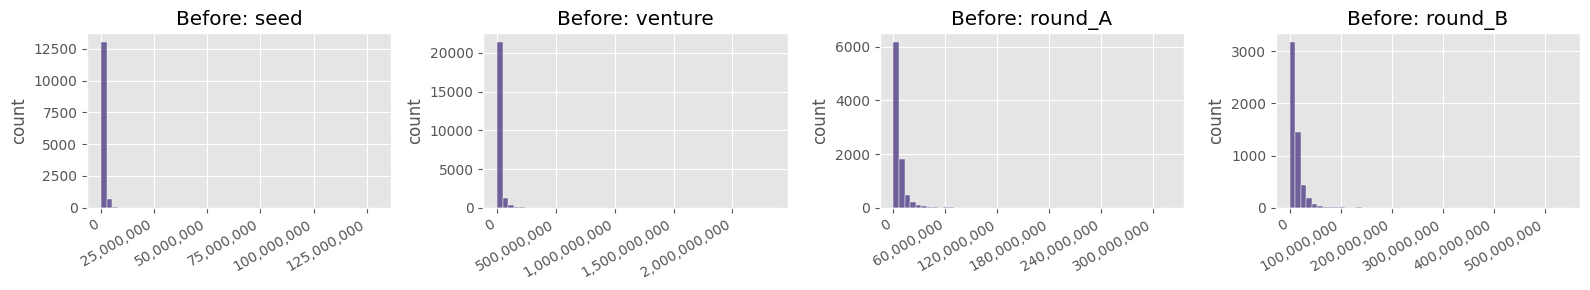

In [3]:
#EDA: Data quality checks and outliers

# 5) Quick data quality checks
print("\n=== Data quality checks ===")
# We count the number of duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Outliers overview using IQR counts per numeric column
print("\nOutlier counts per numeric column (IQR method):")

_numeric_cols = df.select_dtypes(include=[np.number])
_records = []

for col in _numeric_cols.columns:
    series = _numeric_cols[col]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    lower_count = int((series < lower).sum())
    upper_count = int((series > upper).sum())
    _records.append({
        'column': col,
        'lower_outliers': lower_count,
        'upper_outliers': upper_count
    })

# Build the final DataFrame with required columns and sorting by total outliers desc
outlier_counts_df = pd.DataFrame(_records, columns=['column','lower_outliers','upper_outliers'])
outlier_counts_df['total_outliers'] = outlier_counts_df['lower_outliers'] + outlier_counts_df['upper_outliers']
outlier_counts_df = outlier_counts_df.sort_values('total_outliers', ascending=False).drop(columns=['total_outliers'])

# Render outlier counts table as a single scrollable data table
outlier_counts_df

# BEFORE histograms (raw distributions)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    _before_cols = [c for c in ['funding_total_usd_float','seed','venture','round_A','round_B'] if c in df.columns]
    _before_cols = [c for c in _before_cols if (df[c].fillna(0) > 0).any()]
    if _before_cols:
        fig, axes = plt.subplots(1, len(_before_cols), figsize=(4*len(_before_cols), 3))
        if len(_before_cols) == 1:
            axes = [axes]
        # Axis formatting: thousands separators, more ticks, rotated labels
        for ax, c in zip(axes, _before_cols):
            s = df[c]
            s_pos = s[s > 0]
            if len(s_pos) > 0:
                sns.histplot(s_pos, bins=50, ax=ax)
                ax.set_title(f"Before: {c}")
                ax.set_xlabel('')  # removed x-axis label per request
                ax.set_ylabel('count')
                # Use thousands separators and avoid scientific notation
                from matplotlib.ticker import FuncFormatter, MaxNLocator
                ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}" if x >= 1000 else (f"{x:.0f}" if float(x).is_integer() else f"{x:g}")))
                # Increase number of ticks and rotate labels to prevent overlap
                ax.xaxis.set_major_locator(MaxNLocator(nbins=6, prune=None))
                for tick in ax.get_xticklabels():
                    tick.set_rotation(30)
                    tick.set_ha('right')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("Skipping before histograms:", e)

## Initial observations

### Key issues to address

- Source file is not encoded in utf\-8 but rather latin\-1, this may affect date parsing and text fields\.

- funding\_total\_usd is string\-formatted \(dashes, comma\-grouping\) requiring parsing and type conversion\.

- Mixed date columns as strings \(founded\_at, first\_funding\_at, last\_funding\_at\) needing standardized datetime conversion\.

- High concentration of null data points \(state\_code ~24k nulls; founded\_year/month/quarter ~15\.8k each; country\_code, region, city ~11k \.\.\.etc\)\.

- Zero\-inflated and highly skewed funding variables with extreme outliers across rounds and funding types\.

- Inconsistent categorical granularity between category\_list and market; may require normalization or primary category extraction\.

# Parsing and type conversion

In [4]:
# We'll parse and convert the funding_total_usd column to float (funding_total_usd_float)
# The column contains dashes for missing and comma-style grouping. We'll normalize then convert.

# 1) Standardize missing markers: replace '-' and empty strings with NaN
ft = df['funding_total_usd'].astype(str).str.strip()
ft = ft.replace({'-': np.nan, '': np.nan})

# 2) Remove any commas and non-digit characters, keeping digits only
# Some values might have currency symbols or spaces; extract digits
ft_numeric = ft.str.replace(',', '', regex=False).str.extract(r'([0-9]+)', expand=False)

# 3) Convert to numeric (float)
df['funding_total_usd_float'] = pd.to_numeric(ft_numeric, errors='coerce').astype(float)

# 4) Ensure date columns are datetime for logic checks
for col in ['founded_at','first_funding_at','last_funding_at']:
    if df[col].dtype != 'datetime64[ns]':
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 5) Quick check on the first 10 values
comparison_df = df[['funding_total_usd', 'funding_total_usd_float', 'founded_at','first_funding_at','last_funding_at']]
comparison_df.head(10)

,funding_total_usd,funding_total_usd_float,founded_at,first_funding_at,last_funding_at
0,"17,50,000",1750000.0,2012-06-01,2012-06-30,2012-06-30
1,"40,00,000",4000000.0,NaT,2010-06-04,2010-09-23
2,"40,000",40000.0,2012-10-26,2012-08-09,2012-08-09
3,"15,00,000",1500000.0,2011-04-01,2011-04-01,2011-04-01
4,"60,000",60000.0,2014-01-01,2014-08-17,2014-09-26
5,"70,00,000",7000000.0,2011-10-10,2013-05-31,2013-05-31
6,"49,12,393",4912393.0,NaT,2007-01-16,2007-01-16
7,"20,00,000",2000000.0,2007-01-01,2008-03-19,2008-03-19
8,-,NaN,2010-01-01,2014-07-24,2014-07-24
9,"41,250",41250.0,NaT,2014-07-01,2014-07-01


## Category normalization: harmonize category\_list and market

This section creates normalized versions of category\_list and market the following way: we extract a primary category token from category\_list, map common synonyms to a canonical set, and reconcile conflicts between market and the extracted primary category using a whitelist preference\. We then output a quick QA summary with the top 20 categories and a small agreement snapshot\.

In [5]:
# Category normalization: harmonize category_list and market
import re

# 1) Normalize raw text
cat_raw = df.get('category_list')
mrk_raw = df.get('market')

category_list_norm = (
    cat_raw.fillna('')
          .astype(str)
          .str.strip()
)
market_norm = (
    mrk_raw.fillna('')
          .astype(str)
          .str.strip()
)

# Lowercase for consistent comparisons
category_list_norm = category_list_norm.str.lower()
market_norm = market_norm.str.lower()

# 2) Extract primary category token from category_list
# Split by '|' and take the last non-empty token. If none, NaN.
def extract_primary(s: pd.Series) -> pd.Series:
    parts = s.str.split('|')
    # Get last non-empty token per row
    last_tokens = parts.apply(lambda lst: next((t for t in lst[::-1] if t), '' ) if isinstance(lst, list) else '')
    primary = last_tokens.str.strip()
    primary = primary.replace({'': np.nan})
    return primary

primary_category = extract_primary(category_list_norm)

# 3) Canonicalization via simple synonym map
syn_map = {
    'e-commerce': 'ecommerce',
    'e commerce': 'ecommerce',
    'ecommerce': 'ecommerce',
    'biotech': 'biotechnology',
    'biotechnology': 'biotechnology',
    'mobile apps': 'mobile',
    'mobile application': 'mobile',
    'mobile': 'mobile',
    'software': 'software',
    'saas': 'software',
    'adtech': 'advertising',
    'advertising': 'advertising',
    'fintech': 'finance',
    'finance': 'finance',
    'healthtech': 'health',
    'health care': 'health',
    'healthcare': 'health',
    'health': 'health',
    'ai': 'artificial intelligence',
    'machine learning': 'artificial intelligence',
    'artificial intelligence': 'artificial intelligence',
}

def canonicalize(s: pd.Series) -> pd.Series:
    return s.fillna('').map(lambda x: syn_map.get(x, x)).replace({'': np.nan})

primary_category_canonical = canonicalize(primary_category)
market_canonical = canonicalize(market_norm)

# 4) Choose final category
# If market missing, use primary; if both are present but they are different, we take the primary if present in whitelist; else keep market.
whitelist = set(['software','biotechnology','ecommerce','mobile','advertising','finance','health','artificial intelligence'])

final_category = market_canonical.copy()
# Fill missing market with primary
final_category = final_category.where(final_category.notna(), primary_category_canonical)
# Resolve conflicts: if both present and different, prefer primary when in whitelist
conflict_mask = market_canonical.notna() & primary_category_canonical.notna() & (market_canonical != primary_category_canonical)
prefer_primary = conflict_mask & primary_category_canonical.isin(list(whitelist))
final_category = final_category.mask(prefer_primary, primary_category_canonical)

# 5) Assign new columns without overwriting originals
df['category_list_norm'] = category_list_norm
df['market_norm'] = market_norm
df['primary_category'] = primary_category
df['primary_category_canonical'] = primary_category_canonical
df['market_canonical'] = market_canonical
df['final_category'] = final_category

# 6) QA summaries
print("Top 20 final categories:")
df['final_category'].value_counts().head(20)

print("\nAgreement snapshot (primary vs market canonical):")
agree_sample = (
    df.loc[primary_category_canonical.notna() | market_canonical.notna(),
           ['primary_category_canonical','market_canonical']]
      .value_counts()
      .head(20)
)
agree_sample

Top 20 final categories:

Agreement snapshot (primary vs market canonical):


primary_category_canonical  market_canonical   
software                    software               4520
biotechnology               biotechnology          3654
mobile                      mobile                 1671
ecommerce                   ecommerce              1632
curated web                 curated web            1630
enterprise software         enterprise software    1222
clean technology            clean technology       1185
games                       games                  1137
hardware + software         hardware + software    1068
advertising                 advertising             926
health                      health                  907
health and wellness         health and wellness     823
education                   education               782
finance                     finance                 722
manufacturing               manufacturing           708
social media                social media            621
analytics                   analytics               519


# Null Data Points

This block now creates a one\-time deep copy of the original DataFrame \(df\_raw\) before any fixes are applied, and then shows concise before/after samples for rows affected by each rule\. This makes it easy to validate what changed without scanning the entire dataset\.

It is important to identify wether some data points are null because they cannot be registered or if they are yet to be registered\. Here is some criteria we will be using for this dataset:

- Structural impossibility: e\.g\., state\_code is only applicable when country\_code == 'USA'\. If country\_code \!= 'USA', then null state\_code = “not applicable” \(cannot be registered\)\.

- Temporal impossibility: dates before a company’s founding can’t exist \(e\.g\., first\_funding\_at before founded\_at → if missing, may be “not yet” unless status is closed\)\.

- Terminal status: if status in \['closed','acquired'\] and last\_funding\_at is null, we might tag as “unknown/never recorded”\.

- If funding\_rounds \> 0 but last\_funding\_at is null, then the data should exist\.

- funding\_total\_usd \(after parsing\) \> 0 but all round\_\* are zero → likely “data\_quality\_issue\.”

In [6]:
# At the very top of the block, create a pre-fix snapshot if it doesn't already exist
if 'df_raw' not in globals():
    df_raw = df.copy(deep=True)

# 1) Structural: state_code only applicable when country_code == 'USA'
df.loc[df['country_code'].ne('USA') & df['state_code'].isna(), 'state_code'] = 'not applicable'

# 2) Temporal impossibility: dates before founding can't exist
mask_first_before_found = df['first_funding_at'].notna() & df['founded_at'].notna() & (df['first_funding_at'] < df['founded_at'])
df.loc[mask_first_before_found, 'first_funding_at'] = pd.NaT

mask_last_before_found = df['last_funding_at'].notna() & df['founded_at'].notna() & (df['last_funding_at'] < df['founded_at'])
df.loc[mask_last_before_found, 'last_funding_at'] = pd.NaT

# 3) Terminal status handling for missing last_funding_at
mask_missing = df['last_funding_at'].isna()
mask_terminal = df['status'].isin(['closed', 'acquired'])

df['last_funding_na_reason'] = 'present'
df.loc[mask_missing & ~mask_terminal, 'last_funding_na_reason'] = 'not yet recorded or missing'
df.loc[mask_missing & mask_terminal, 'last_funding_na_reason'] = 'never recorded before being closed/acquired'

# 4) Flag: funding_rounds > 0 but last_funding_at is null
df['missing_last_funding_but_rounds'] = (df['funding_rounds'].fillna(0) > 0) & df['last_funding_at'].isna()

# 5) Flag: funding_total_usd_float > 0 but all round_* are zero
round_cols = [c for c in df.columns if c.startswith('round_')]
all_rounds_zero = (df[round_cols].fillna(0).sum(axis=1) == 0)
df['funding_rounds_mismatch'] = (df['funding_total_usd_float'].fillna(0) > 0) & all_rounds_zero

# 6) founded_year consistency with founded_at
founded_year_from_date = df['founded_at'].dt.year
incons_year = df['founded_year'].notna() & founded_year_from_date.notna() & (df['founded_year'] != founded_year_from_date)
df.loc[incons_year, 'founded_year'] = founded_year_from_date[incons_year]

# Fill founded_year from founded_at where missing
df.loc[df['founded_year'].isna() & founded_year_from_date.notna(), 'founded_year'] = founded_year_from_date[df['founded_year'].isna() & founded_year_from_date.notna()]

# 7) Derive founded_month and founded_quarter from founded_at where missing
df.loc[df['founded_month'].isna() & df['founded_at'].notna(), 'founded_month'] = df.loc[df['founded_month'].isna() & df['founded_at'].notna(), 'founded_at'].dt.strftime('%Y-%m')

def quarter_str(dt_series):
    q = ((dt_series.dt.month - 1) // 3 + 1).astype('Int64')
    return dt_series.dt.year.astype('Int64').astype(str) + '-Q' + q.astype(str)

df.loc[df['founded_quarter'].isna() & df['founded_at'].notna(), 'founded_quarter'] = quarter_str(df.loc[df['founded_quarter'].isna() & df['founded_at'].notna(), 'founded_at'])

# Summary 
results = {
    'first_before_found_fixed': int(mask_first_before_found.sum()),
    'last_before_found_fixed': int(mask_last_before_found.sum()),
    'terminal_status_missing_last_funding': int((df['last_funding_na_reason']=='never recorded before being closed/acquired').sum()),
    'missing_last_funding_but_rounds': int(df['missing_last_funding_but_rounds'].sum()),
    'funding_rounds_mismatch': int(df['funding_rounds_mismatch'].sum()),
}
results_df = pd.DataFrame(list(results.items()), columns=['action','count'])
print(results_df)

                                 action  count
0              first_before_found_fixed   2739
1               last_before_found_fixed   1600
2  terminal_status_missing_last_funding    269
3       missing_last_funding_but_rounds   1606
4               funding_rounds_mismatch  28149


# Handling zero\-inflation, skew, and extreme outliers in funding variables

We now enhance the outlier handling section by adding AFTER histograms for a small set of representative funding variables\. These plots compare capped values and their log1p transforms to the original BEFORE histograms, helping verify that the treatments reduce skew while preserving distributional signal\.

=== Handling zero-inflation and outliers in funding variables ===
Columns treated: ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H', 'funding_total_usd_float']
Upper caps (99.5th percentile): {'seed': 6081670.000000027, 'venture': 195562802.1799999, 'equity_crowdfunding': 12306526.229999894, 'undisclosed': 118947380.93000004, 'convertible_note': 40523941.36000019, 'debt_financing': 524640000.0000003, 'angel': 15000000.0, 'grant': 195425000.0000011, 'private_equity': 800260000.0000209, 'post_ipo_equity': 1396568208.1750052, 'post_ipo_debt': 4948999999.9999895, 'secondary_market': 655356514.14, 'product_crowdfunding': 49755999.99999992, 'round_A': 63722105.99999984, 'round_B': 105539999.99999906, 'round_C': 154100000.0000008, 'round_D': 25000

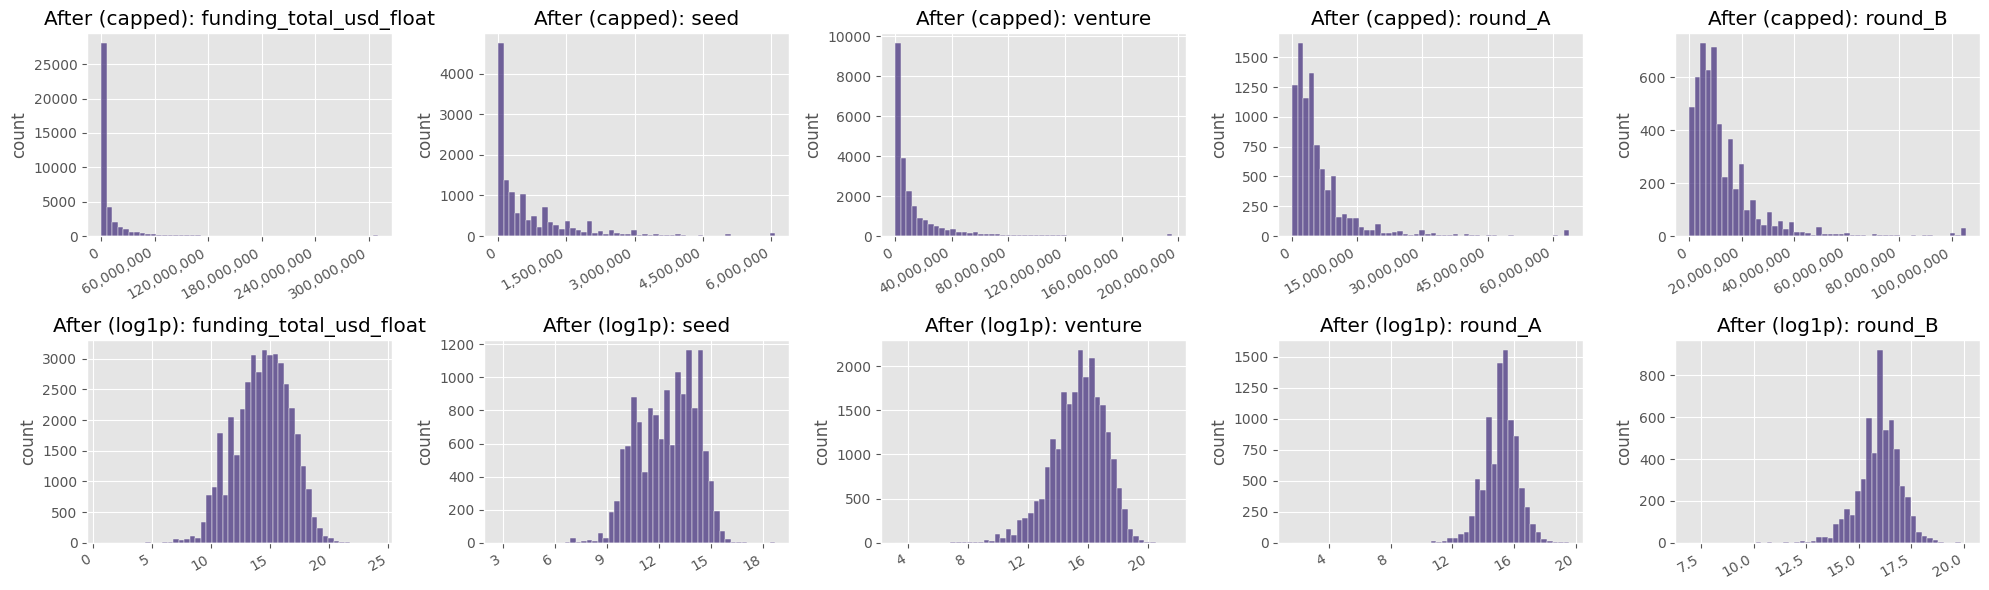

In [7]:
# Handling zero-inflation, skew, and extreme outliers in funding variables

# 1) Identify numeric funding columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
round_cols = [c for c in df.columns if c.startswith('round_')]
fund_cols_candidates = set([
    'seed','venture','equity_crowdfunding','undisclosed','convertible_note',
    'debt_financing','angel','grant','private_equity','post_ipo_equity',
    'post_ipo_debt','secondary_market','product_crowdfunding','funding_total_usd_float'
])
fund_cols = [c for c in num_cols if (c in fund_cols_candidates or c in round_cols)]

if not fund_cols:
    print("No numeric funding columns detected; skipping.")
else:
    # 2) Positive masks and log1p transforms
    for c in fund_cols:
        pos_mask = df[c].fillna(0) > 0
        df[f'{c}_gt0'] = pos_mask
        # log1p only for positive values; keep NaN where original was NaN
        arr = df[c].where(pos_mask)
        df[f'log1p_{c}'] = np.log1p(arr)

    # 3) Winsorize at 99.5th percentile per column (upper cap only)
    caps = {}
    for c in fund_cols:
        series = df[c]
        # Compute cap on positive values to avoid zero dominating quantiles
        cap = series[series > 0].quantile(0.995)
        if pd.notna(cap) and np.isfinite(cap):
            caps[c] = float(cap)
            df[f'{c}_capped'] = series.clip(upper=cap)
        else:
            caps[c] = None
            df[f'{c}_capped'] = series  # unchanged

    # 4) Zero/nonzero flags and sparsity
    sparsity = []
    for c in fund_cols:
        s = df[c]
        n = len(s)
        pos = int((s.fillna(0) > 0).sum())
        zeros = int((s == 0).sum())
        na = int(s.isna().sum())
        sparsity.append({
            'column': c,
            'positive_count': pos,
            'zero_count': zeros,
            'na_count': na,
            'positive_ratio': round(pos / n, 4)
        })
    sparsity_df = pd.DataFrame(sparsity).sort_values('positive_ratio')

    # 5) Compact monitoring summary with original vs capped max
    summary_rows = []
    for c in fund_cols:
        s = df[c]
        sc = df[f'{c}_capped']
        summary_rows.append({
            'column': c,
            'orig_min': float(np.nanmin(s.values)) if s.notna().any() else np.nan,
            'orig_p99_5': float(s[s>0].quantile(0.995)) if (s>0).any() else np.nan,
            'orig_max': float(np.nanmax(s.values)) if s.notna().any() else np.nan,
            'capped_max': float(np.nanmax(sc.values)) if sc.notna().any() else np.nan,
        })
    outlier_treatment_summary = pd.DataFrame(summary_rows)

    print("=== Handling zero-inflation and outliers in funding variables ===")
    print("Columns treated:", fund_cols)
    print("Upper caps (99.5th percentile):", caps)
    print("\nSparsity (sorted by positive ratio, few positives first):")
    sparsity_df
    print("\nOriginal vs capped max values (first 15):")
    outlier_treatment_summary.head(15)

# AFTER histograms (post-treatment)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    _after_cols = [c for c in ['funding_total_usd_float','seed','venture','round_A','round_B'] if c in df.columns]
    _after_cols = [c for c in _after_cols if (df[c].fillna(0) > 0).any()]
    if _after_cols:
        fig, axes = plt.subplots(2, len(_after_cols), figsize=(4*len(_after_cols), 6))
        if len(_after_cols) == 1:
            axes = np.array([[axes[0]], [axes[1]]])
        for j, c in enumerate(_after_cols):
            # Capped values histogram (positive only)
            s_cap = df[f'{c}_capped'] if f'{c}_capped' in df.columns else df[c]
            s_cap_pos = s_cap[s_cap > 0]
            if len(s_cap_pos) > 0:
                sns.histplot(s_cap_pos, bins=50, ax=axes[0, j])
                axes[0, j].set_title(f"After (capped): {c}")
                axes[0, j].set_xlabel('')  # removed x-axis label per request
                axes[0, j].set_ylabel('count')
                from matplotlib.ticker import FuncFormatter, MaxNLocator
                axes[0, j].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}" if x >= 1000 else (f"{x:.0f}" if float(x).is_integer() else f"{x:g}")))
                axes[0, j].xaxis.set_major_locator(MaxNLocator(nbins=6, prune=None))
                for tick in axes[0, j].get_xticklabels():
                    tick.set_rotation(30)
                    tick.set_ha('right')

            # Log1p transform histogram
            s_log = df[f'log1p_{c}'] if f'log1p_{c}' in df.columns else None
            if s_log is not None:
                sns.histplot(s_log.dropna(), bins=50, ax=axes[1, j])
                axes[1, j].set_title(f"After (log1p): {c}")
                axes[1, j].set_xlabel('')  # removed x-axis label per request
                axes[1, j].set_ylabel('count')
                from matplotlib.ticker import MaxNLocator
                axes[1, j].xaxis.set_major_locator(MaxNLocator(nbins=6, prune=None))
                for tick in axes[1, j].get_xticklabels():
                    tick.set_rotation(30)
                    tick.set_ha('right')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("Skipping after histograms:", e)

In [8]:
# Preview the generated monitoring tables for validation
outputs = []
try:
    print("Top sparsity entries:")
    outputs.append(sparsity_df.head(15))
except Exception as e:
    print("sparsity_df not available:", e)

try:
    print("\nOriginal vs capped max (first 15):")
    outputs.append(outlier_treatment_summary.head(15))
except Exception as e:
    print("outlier_treatment_summary not available:", e)

# Return the preview objects if any
outputs[-1] if outputs else None

Top sparsity entries:

Original vs capped max (first 15):


,column,orig_min,orig_p99_5,orig_max,capped_max
0,seed,0.0,6.081670e+06,1.300000e+08,6.081670e+06
1,venture,0.0,1.955628e+08,2.351000e+09,1.955628e+08
2,equity_crowdfunding,0.0,1.230653e+07,2.500000e+07,1.230653e+07
3,undisclosed,0.0,1.189474e+08,2.924328e+08,1.189474e+08
4,convertible_note,0.0,4.052394e+07,3.000000e+08,4.052394e+07
5,debt_financing,0.0,5.246400e+08,3.007950e+10,5.246400e+08
6,angel,0.0,1.500000e+07,6.359026e+07,1.500000e+07
7,grant,0.0,1.954250e+08,7.505000e+08,1.954250e+08
8,private_equity,0.0,8.002600e+08,3.500000e+09,8.002600e+08
9,post_ipo_equity,0.0,1.396568e+09,4.700000e+09,1.396568e+09


## Median investment by startup status

This section computes and visualizes the median investment amounts for startups by status, focusing on Operating vs Acquired\. It ensures the funding\_total\_usd\_float column is available \(parsing from funding\_total\_usd if needed\), filters to relevant records with positive investments, computes medians with grouping, prints a compact summary, and renders a Seaborn boxplot on a log10 scale with improved tick formatting\. 

=== Median investment by status (USD) ===
Acquired: 8,382,400
Operating: 1,757,977


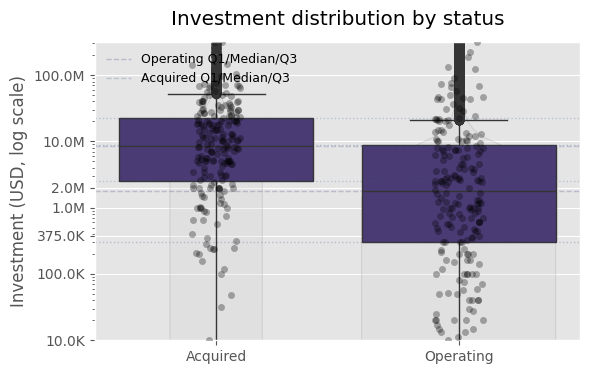

In [9]:
# Median investment by status (Operating vs Acquired)
# 1) Ensure funding_total_usd_float exists; if missing, parse from funding_total_usd
if 'funding_total_usd_float' not in df.columns or df['funding_total_usd_float'].isna().all():
    ft = df['funding_total_usd'].astype(str).str.strip()
    ft = ft.replace({'-': np.nan, '': np.nan})
    ft_numeric = ft.str.replace(',', '', regex=False).str.extract(r'([0-9]+)', expand=False)
    df['funding_total_usd_float'] = pd.to_numeric(ft_numeric, errors='coerce').astype(float)

# Filter to operating/acquired and positive investments
status_series = df['status'].astype(str).str.strip().str.lower()
mask_status = status_series.isin(['operating','acquired'])
mask_positive = df['funding_total_usd_float'].fillna(0) > 0
filtered = df.loc[mask_status & mask_positive, ['status', 'funding_total_usd_float']].copy()

# Standardize status labels to title case
filtered['status'] = filtered['status'].astype(str).str.strip().str.lower().map({'operating':'Operating','acquired':'Acquired'})

# 2) Compute medians
medians_df = filtered.groupby('status', as_index=False)['funding_total_usd_float'].median()

# Nicely formatted summary with thousands separators
print('=== Median investment by status (USD) ===')
for _, row in medians_df.iterrows():
    status_label = row['status']
    median_val = row['funding_total_usd_float']
    try:
        formatted = f"{int(median_val):,}" if np.isfinite(median_val) else 'NaN'
    except Exception:
        formatted = str(median_val)
    print(f"{status_label}: {formatted}")

# 3) Plot boxplot comparing distributions
# Make sure there's at least one record per group
group_counts = filtered['status'].value_counts()
if set(['Operating','Acquired']).issubset(set(group_counts.index)) and (group_counts['Operating'] > 0) and (group_counts['Acquired'] > 0):
    try:
        # Build plot_df and capped y values for dynamic limits
        plot_df = filtered.copy()
        y_cap = plot_df['funding_total_usd_float'].copy()
        # Use a moderate cap to align scale for whiskers (same as earlier winsorization if available)
        cap_val = y_cap[y_cap > 0].quantile(0.995) if (y_cap > 0).any() else np.nan
        if pd.notna(cap_val):
            y_cap = y_cap.clip(upper=cap_val)
        plot_df['y_cap'] = y_cap

        # Downsample jitter points per group (max 200) to reduce clutter
        def sample_group(g):
            return g.sample(n=min(len(g), 200), random_state=42) if len(g) > 200 else g
        jitter_df = plot_df.groupby('status', group_keys=False).apply(sample_group)

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.boxplot(data=plot_df, x='status', y='y_cap', ax=ax)
        # Overlay a light violin for distribution shape
        try:
            sns.violinplot(data=plot_df, x='status', y='y_cap', ax=ax, inner=None, color='lightgrey', alpha=0.25)
        except Exception:
            pass
        # Add jittered points for visibility (reduced sample)
        try:
            sns.stripplot(data=jitter_df, x='status', y='y_cap', ax=ax, color='black', alpha=0.3, jitter=True)
        except Exception:
            pass

        # Keep log scale with compatibility
        try:
            ax.set_yscale('log', base=10)
        except Exception:
            ax.set_yscale('log')

        # Sensible y-limits: 1st and 99.5th percentiles on positive values, ensure >= 1 decade span
        pos_vals = plot_df['y_cap'][plot_df['y_cap'] > 0]
        y_min = pos_vals.quantile(0.01)
        y_max = pos_vals.quantile(0.995)
        # Fallbacks
        if (pd.isna(y_min)) or (y_min <= 0):
            y_min = float(pos_vals.min()) if len(pos_vals) else 1e3
        if pd.isna(y_max):
            y_max = float(pos_vals.max()) if len(pos_vals) else 1e6
        # Ensure positive and valid order
        y_min = max(y_min, 1e-3)
        if y_min >= y_max:
            y_max = y_min * 10.0
        # Ensure at least one decade span; pad symmetrically in log space
        log_min, log_max = np.log10(y_min), np.log10(y_max)
        if (log_max - log_min) < 1.0:
            mid = 0.5 * (log_min + log_max)
            log_min = mid - 0.5
            log_max = mid + 0.5
            y_min, y_max = 10**log_min, 10**log_max
        ax.set_ylim(y_min, y_max)

        # Overall quartiles on positive capped values (for tick inclusion)
        q1 = pos_vals.quantile(0.25)
        q2 = pos_vals.quantile(0.5)
        q3 = pos_vals.quantile(0.75)

        # Group-specific quartiles and reference lines (colors from current palette)
        palette = sns.color_palette()
        color_map = {'Operating': palette[0] if len(palette) > 0 else 'C0',
                     'Acquired': palette[1] if len(palette) > 1 else 'C1'}
        guide_handles = []
        guide_labels = []
        for status_key in ['Operating','Acquired']:
            grp_vals = plot_df.loc[plot_df['status'] == status_key, 'y_cap']
            grp_pos = grp_vals[grp_vals > 0]
            if len(grp_pos) == 0:
                continue
            gq1 = grp_pos.quantile(0.25)
            gq2 = grp_pos.quantile(0.5)
            gq3 = grp_pos.quantile(0.75)
            col = color_map[status_key]
            # Q1 and Q3 as dotted
            line1 = ax.axhline(y=gq1, linestyle=':', color=col, alpha=0.25, linewidth=1)
            line3 = ax.axhline(y=gq3, linestyle=':', color=col, alpha=0.25, linewidth=1)
            # Median as dashed
            linem = ax.axhline(y=gq2, linestyle='--', color=col, alpha=0.25, linewidth=1)
            # For legend, create a single proxy line per status showing styles
            # We'll use the median (dashed) as representative in legend text mentioning Q1/Median/Q3
            guide_handles.append(linem)
            guide_labels.append(f"{status_key} Q1/Median/Q3")

        # Combined y-axis ticks: union of quartiles and log-spaced decade ticks within limits
        cur_ymin, cur_ymax = ax.get_ylim()
        base_log_ticks = [1e4, 1e5, 1e6, 1e7, 1e8]
        ref_ticks = [t for t in base_log_ticks if (t >= cur_ymin and t <= cur_ymax)]
        quartile_ticks = [t for t in [q1, q2, q3] if pd.notna(t) and np.isfinite(t) and (t > 0)]
        all_ticks = ref_ticks + quartile_ticks
        # Deduplicate and sort on log scale
        if all_ticks:
            all_ticks = sorted(all_ticks, key=lambda v: np.log10(v))
            dedup = []
            for t in all_ticks:
                if not dedup:
                    dedup.append(t)
                else:
                    if abs(np.log10(t) - np.log10(dedup[-1])) > 1e-6:
                        dedup.append(t)
            ax.set_yticks(dedup)

        # Formatter: thousands separators with abbreviated magnitudes
        from matplotlib.ticker import FuncFormatter
        def abbr_fmt(x):
            try:
                if x >= 1e9:
                    return f"{x/1e9:.1f}B"
                if x >= 1e6:
                    return f"{x/1e6:.1f}M"
                if x >= 1e3:
                    return f"{x/1e3:.1f}K"
                # fall back to int if close
                return f"{int(x):,}" if float(x).is_integer() else f"{x:g}"
            except Exception:
                return str(x)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: abbr_fmt(x)))

        # Titles and labels
        ax.set_title('Investment distribution by status', pad=12)
        # Guard against undefined subtitle
        try:
            if 'subtitle' in globals() and isinstance(subtitle, str):
                ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha='center', va='bottom', fontsize=10)
        except Exception:
            pass
        ax.set_xlabel('')
        ax.set_ylabel('Investment (USD, log scale)')

        # Legend for group quartile guides
        if guide_handles:
            ax.legend(guide_handles, guide_labels, loc='upper left', frameon=False, fontsize=9)

        # Rotate x tick labels to 0°
        for tick in ax.get_xticklabels():
            tick.set_rotation(0)
            tick.set_ha('center')

        # Increase top margin to reduce title/subtitle overlap
        plt.tight_layout(rect=(0, 0, 1, 0.96))
        plt.show()
    except Exception as e:
        print('Plotting skipped due to error:', e)
else:
    print('Insufficient data to plot: need positive investment records for both Operating and Acquired.')

## Hot sectors: Venture\-type funding rounds in the last decade

We identify the last decade relative to the maximum year found across first\_funding\_at and last\_funding\_at in the dataset\. Venture\-type rounds include any positive value in the venture amount or any of the stage columns round\_A through round\_H, counting each positive stage as one round and counting venture as an additional round if present\. Sectors are taken from final\_category if available, otherwise from market, and if both are missing we fall back to the primary token extracted from category\_list\. We then tally the number of venture\-type rounds per sector over this period, report the top 15 sectors, provide a short narrative, and plot a horizontal bar chart\.

Reference year: 2015 - Last decade window: [2006, 2015]
Top 15 sectors by venture-type rounds (last decade):
In the last decade, the busiest venture activity clusters around: software (6011), biotechnology (4974), mobile (2546). Among the top 15, analytics sits at the lower end with 600 rounds, indicating a long tail of smaller sectors.


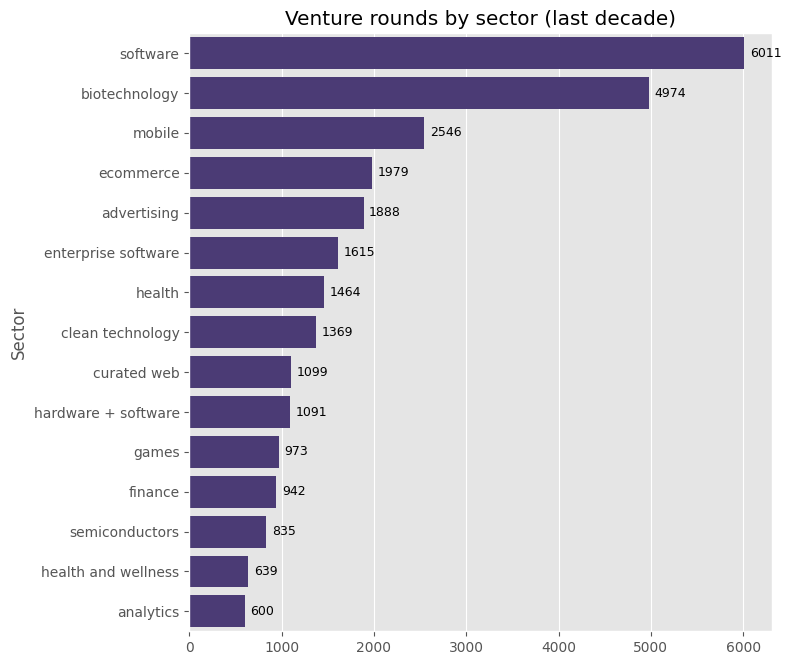

In [10]:
# Hot sectors: Which sectors have received the most Venture-type funding rounds in the last decade?
# Assumes df is available and prior preprocessing (dates and categories) may have been run.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep requested variable names
venture_round_cols = [c for c in df.columns if c.startswith('round_') and c.split('_')[-1] in list('ABCDEFGH')]
# Ensure consistent ordering A..H
venture_round_cols = sorted(venture_round_cols, key=lambda x: x.split('_')[-1])

# Determine reference year from max date across first_funding_at and last_funding_at
# Be robust if columns are missing or not datetime
first_dates = df['first_funding_at'] if 'first_funding_at' in df.columns else pd.Series([pd.NaT]*len(df))
last_dates = df['last_funding_at'] if 'last_funding_at' in df.columns else pd.Series([pd.NaT]*len(df))

# Ensure datetime dtype
first_dates = pd.to_datetime(first_dates, errors='coerce')
last_dates = pd.to_datetime(last_dates, errors='coerce')

max_first = first_dates.max()
max_last = last_dates.max()
ref_year = int(max(d for d in [max_first, max_last] if pd.notna(d)).year) if any(pd.notna(x) for x in [max_first, max_last]) else None

if ref_year is None:
    print("No valid funding dates found to determine the last decade. Skipping analysis.")
else:
    start_year = ref_year - 9

    # Build sector_final with fallbacks: final_category -> market -> primary token from category_list
    if 'final_category' in df.columns and df['final_category'].notna().any():
        sector_final = df['final_category'].copy()
    else:
        # fallback chain
        fallback = pd.Series([np.nan]*len(df))
        if 'market' in df.columns:
            fallback = df['market'].where(df['market'].notna(), fallback)
        # derive primary token from category_list if still missing
        need = fallback.isna()
        if need.any() and 'category_list' in df.columns:
            cat = df['category_list'].astype(str).str.strip().str.split('|')
            # take the last non-empty token
            prim = cat.apply(lambda lst: next((t for t in lst[::-1] if isinstance(t, str) and len(t)>0), np.nan) if isinstance(lst, list) else np.nan)
            fallback = fallback.where(~need, prim)
        sector_final = fallback

    # Normalize sector text for grouping
    sector_final = sector_final.astype(str).str.strip()
    sector_final = sector_final.replace({'': np.nan, 'nan': np.nan, 'NaN': np.nan})

    # Attach to df without overwriting earlier columns
    df['sector_final'] = sector_final

    # Filter rows that have at least one of the two funding date columns within the last decade
    # Compute a proxy year per row: prefer last_funding_at year, else first_funding_at year
    row_year = last_dates.dt.year.fillna(first_dates.dt.year)
    time_mask = row_year.between(start_year, ref_year, inclusive='both')

    # Identify venture-type rounds: venture > 0 OR any round_A..round_H > 0
    venture_positive = (df['venture'].fillna(0) > 0) if 'venture' in df.columns else pd.Series([False]*len(df))
    round_pos_flags = []
    for c in venture_round_cols:
        if c in df.columns:
            round_pos_flags.append((df[c].fillna(0) > 0))
        else:
            round_pos_flags.append(pd.Series([False]*len(df)))

    if len(round_pos_flags) == 0:
        any_round_pos = venture_positive
        round_counts = venture_positive.astype(int)
    else:
        round_pos_matrix = pd.concat(round_pos_flags, axis=1) if round_pos_flags else pd.DataFrame(index=df.index)
        # Count each positive stage as 1; add venture as an additional 1 if positive
        stage_count = round_pos_matrix.sum(axis=1).astype(int)
        round_counts = stage_count + venture_positive.astype(int)
        any_round_pos = (stage_count > 0) | venture_positive

    # Combine masks
    eligible_mask = time_mask & any_round_pos & df['sector_final'].notna()

    if not eligible_mask.any():
        print("No qualifying venture-type rounds found in the last decade window. Nothing to report.")
    else:
        # Build a tidy DataFrame where each company contributes as many rows as the number of positive rounds
        # For efficiency, we aggregate counts directly without exploding rows.
        venture_last_decade_df = df.loc[eligible_mask, ['sector_final']].copy()
        venture_last_decade_df['rounds_count'] = round_counts.loc[eligible_mask].astype(int)

        # Aggregate counts per sector
        venture_sector_counts = (
            venture_last_decade_df.groupby('sector_final', as_index=False)['rounds_count'].sum()
            .rename(columns={'sector_final': 'sector'})
            .sort_values('rounds_count', ascending=False)
        )

        # Show top 15
        top15 = venture_sector_counts.head(15)
        print("Reference year:", ref_year, "- Last decade window:", f"[{start_year}, {ref_year}]")
        print("Top 15 sectors by venture-type rounds (last decade):")
        top15

        # Short narrative
        if len(top15) > 0:
            leaders = top15.iloc[0:3]
            leader_list = ", ".join([f"{row['sector']} ({int(row['rounds_count'])})" for _, row in leaders.iterrows()])
            tail = top15.iloc[-1]
            print(f"In the last decade, the busiest venture activity clusters around: {leader_list}. "
                  f"Among the top 15, {tail['sector']} sits at the lower end with {int(tail['rounds_count'])} rounds, indicating a long tail of smaller sectors.")

        # Plot horizontal bar chart
        try:
            fig_height = max(4, 0.35 * len(top15) + 1.5)
            plt.figure(figsize=(8, fig_height))
            ax = sns.barplot(data=top15, y='sector', x='rounds_count', orient='h')
            ax.set_title('Venture rounds by sector (last decade)')
            ax.set_xlabel('')
            ax.set_ylabel('Sector')
            # Add value labels at end of bars
            for p in ax.patches:
                width = p.get_width()
                y = p.get_y() + p.get_height() / 2
                ax.text(width + max(top15['rounds_count']) * 0.01, y, f"{int(width)}", va='center', ha='left', fontsize=9)
            # Tight layout to avoid overlap
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("Plotting skipped due to error:", e)